In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movies = pd.read_csv("recommender_movies.csv")
ratings = pd.read_csv("recommender_ratings.csv")

movies.head()

,movie_id,title,genre
0,1,Avengers,Action
1,2,Iron Man,Action
2,3,Captain America,Action
3,4,Thor,Action
4,5,Doctor Strange,Action


In [3]:
ratings.head()

,user_id,movie_id,rating
0,18,10,2
1,67,8,2
2,32,15,2
3,27,10,2
4,90,17,1


In [4]:
data = pd.merge(ratings, movies, on="movie_id")

data.head()

,user_id,movie_id,rating,title,genre
0,18,10,2,Avatar,Sci-Fi
1,67,8,2,Inception,Sci-Fi
2,32,15,2,Toy Story,Animation
3,27,10,2,Avatar,Sci-Fi
4,90,17,1,Coco,Animation


In [5]:
data.shape

(1200, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   user_id   1200 non-null   int64 
 1   movie_id  1200 non-null   int64 
 2   rating    1200 non-null   int64 
 3   title     1200 non-null   object
 4   genre     1200 non-null   object
dtypes: int64(3), object(2)
memory usage: 47.0+ KB


In [7]:
print("Number of users:", data['user_id'].nunique())
print("Number of movies:", data['title'].nunique())

Number of users: 120
Number of movies: 20


In [8]:
data.groupby("title")["rating"].mean().sort_values(ascending=False).head(10)

title
Finding Nemo       3.365385
Joker              3.345455
Coco               3.212121
The Godfather      3.190476
La La Land         3.171429
Iron Man           3.133333
Captain America    3.116667
Forrest Gump       3.100000
Doctor Strange     3.093750
Avengers           3.035088
Name: rating, dtype: float64

In [9]:
data.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

title
La La Land         70
The Notebook       69
Coco               66
Thor               66
Doctor Strange     64
The Dark Knight    63
Titanic            63
The Godfather      63
Frozen             62
The Matrix         62
Name: rating, dtype: int64

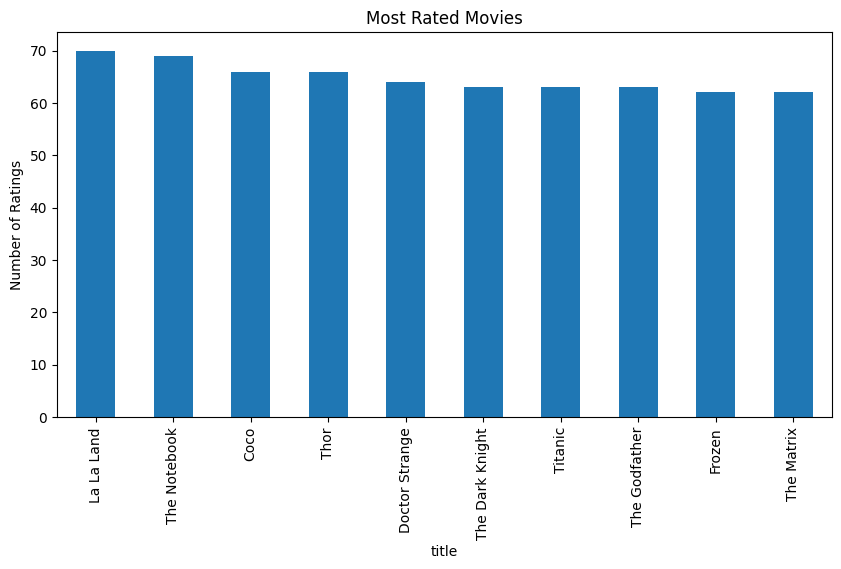

In [10]:
top_movies = data.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

top_movies.plot(kind="bar", figsize=(10,5))
plt.title("Most Rated Movies")
plt.ylabel("Number of Ratings")
plt.show()

In [11]:
user_movie_matrix = data.pivot_table(
    index="user_id",
    columns="title",
    values="rating"
)

In [12]:
user_movie_matrix = user_movie_matrix.fillna(0)

user_movie_matrix.head()

title,Avatar,Avengers,Captain America,Coco,Doctor Strange,Finding Nemo,Forrest Gump,Frozen,Inception,Interstellar,Iron Man,Joker,La La Land,The Dark Knight,The Godfather,The Matrix,The Notebook,Thor,Titanic,Toy Story
user_id,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,2.0,5.0,0.0,0.0,0.0,2.0,3.5
2,0.0,0.0,3.0,0.0,4.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0
3,3.0,4.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,5.0,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,2.5,2.0,0.0,0.0,2.0,2.0,0.0,0.0,4.0,0.0,0.0,5.0
5,2.5,1.0,5.0,4.5,2.0,2.0,3.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,2.0,4.0,0.0,0.0,3.0,1.0


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

In [14]:
movie_similarity = cosine_similarity(user_movie_matrix.T)

In [15]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

movie_similarity_df.head()

title,Avatar,Avengers,Captain America,Coco,Doctor Strange,Finding Nemo,Forrest Gump,Frozen,Inception,Interstellar,Iron Man,Joker,La La Land,The Dark Knight,The Godfather,The Matrix,The Notebook,Thor,Titanic,Toy Story
title,,,,,,,,,,,,,,,,,,,,
Avatar,1.000000,0.321093,0.368693,0.242682,0.315920,0.239556,0.331580,0.246559,0.152046,0.322471,0.341593,0.331853,0.352371,0.372297,0.224409,0.323110,0.279847,0.356100,0.318601,0.256823
Avengers,0.321093,1.000000,0.298854,0.339574,0.326788,0.277396,0.434693,0.368562,0.433426,0.274969,0.217647,0.443771,0.252203,0.360203,0.266406,0.345229,0.209667,0.408764,0.268951,0.250098
Captain America,0.368693,0.298854,1.000000,0.346474,0.325440,0.236165,0.311998,0.320401,0.259547,0.401347,0.295576,0.258495,0.316478,0.319547,0.370746,0.330007,0.273349,0.288632,0.306521,0.324489
Coco,0.242682,0.339574,0.346474,1.000000,0.401841,0.223658,0.387101,0.400083,0.256088,0.302033,0.315666,0.303776,0.452260,0.347475,0.506133,0.413941,0.374009,0.330823,0.370903,0.322153
Doctor Strange,0.315920,0.326788,0.325440,0.401841,1.000000,0.276501,0.221561,0.251907,0.256874,0.331127,0.295651,0.476264,0.328395,0.292921,0.478677,0.406411,0.482428,0.414182,0.366641,0.245184


In [16]:
def recommend_movies(movie_name, num_recommendations=5):
    
    # get similarity scores for the movie
    similar_scores = movie_similarity_df[movie_name]
    
    # sort movies by similarity
    similar_movies = similar_scores.sort_values(ascending=False)
    
    # remove the movie itself
    similar_movies = similar_movies.drop(movie_name)
    
    # return top movies
    return similar_movies.head(num_recommendations)

In [17]:
# similar_scores = movie_similarity_df[movie_name]

In [18]:
def recommend_movies(movie_name, num_recommendations=5):
    
    # get similarity scores for the movie
    similar_scores = movie_similarity_df[movie_name]
    
    # sort movies by similarity
    similar_movies = similar_scores.sort_values(ascending=False)
    
    # remove the movie itself
    similar_movies = similar_movies.drop(movie_name)
    
    # return top movies
    return similar_movies.head(num_recommendations)

In [19]:
recommend_movies("Thor")

title
Titanic           0.424349
Doctor Strange    0.414182
Avengers          0.408764
Joker             0.379562
Finding Nemo      0.377229
Name: Thor, dtype: float64

In [20]:
movies["title"].unique()

array(['Avengers', 'Iron Man', 'Captain America', 'Thor',
       'Doctor Strange', 'The Dark Knight', 'Interstellar', 'Inception',
       'The Matrix', 'Avatar', 'Titanic', 'The Notebook', 'La La Land',
       'Frozen', 'Toy Story', 'Finding Nemo', 'Coco', 'Joker',
       'The Godfather', 'Forrest Gump'], dtype=object)

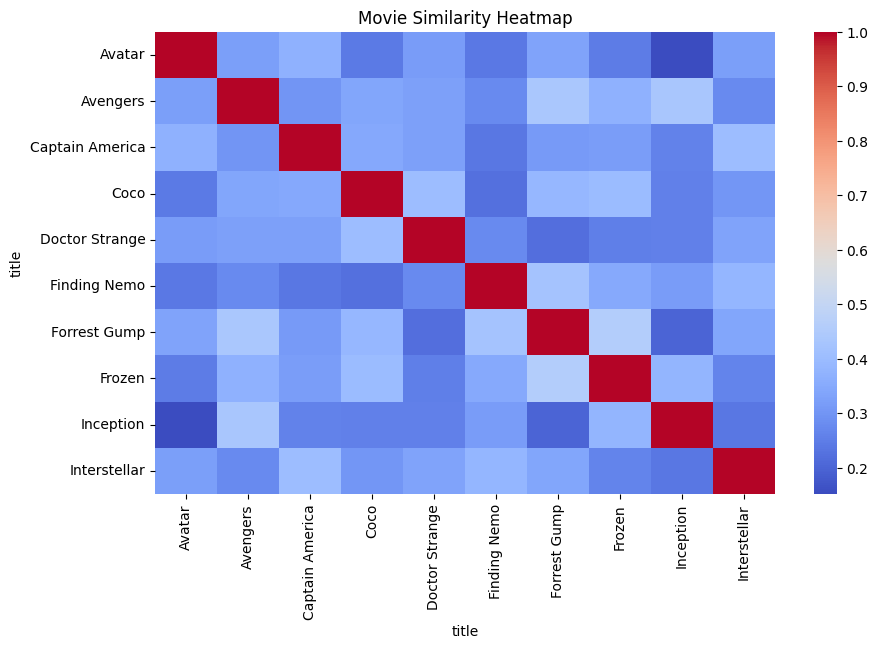

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(movie_similarity_df.iloc[:10, :10], cmap="coolwarm")
plt.title("Movie Similarity Heatmap")
plt.show()

In [22]:
movie = input("Enter a movie name: ")

print("Recommended Movies:")
print(recommend_movies(movie))

Enter a movie name:  Thor


Recommended Movies:
title
Titanic           0.424349
Doctor Strange    0.414182
Avengers          0.408764
Joker             0.379562
Finding Nemo      0.377229
Name: Thor, dtype: float64


In [23]:
movie_stats = data.groupby("title").agg(
    average_rating=("rating","mean"),
    rating_count=("rating","count")
)

movie_stats.head()

,average_rating,rating_count
title,,
Avatar,2.880000,50
Avengers,3.035088,57
Captain America,3.116667,60
Coco,3.212121,66
Doctor Strange,3.093750,64


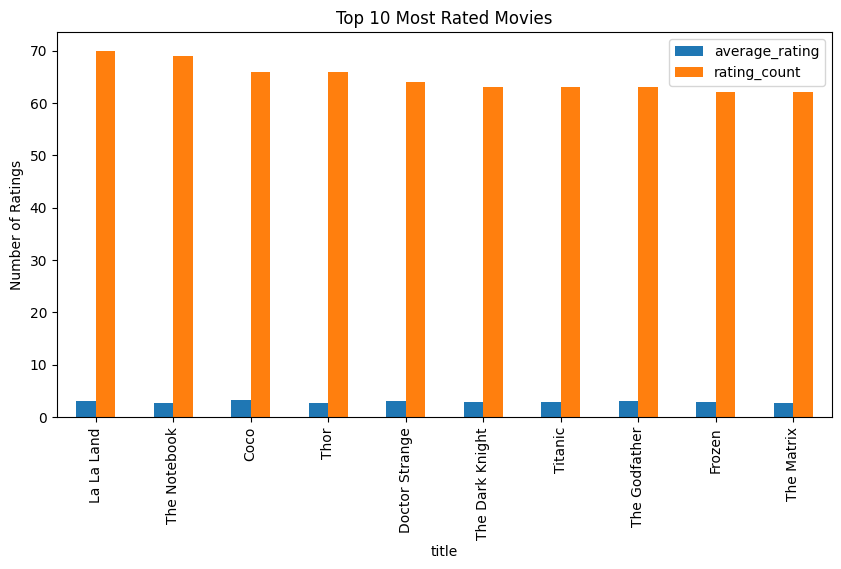

In [24]:
movie_stats.sort_values("rating_count", ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Most Rated Movies")
plt.ylabel("Number of Ratings")
plt.show()

In [25]:
def recommend_movies(movie_name, num_recommendations=5):

    similar_scores = movie_similarity_df[movie_name]

    similar_movies = similar_scores.sort_values(ascending=False)

    similar_movies = similar_movies.drop(movie_name)

    recommended = similar_movies.head(num_recommendations)

    return recommended

In [26]:
recommend_movies("Avengers")

title
Joker           0.443771
Forrest Gump    0.434693
Inception       0.433426
Thor            0.408764
Frozen          0.368562
Name: Avengers, dtype: float64

In [27]:
movie = input("Enter a movie name: ")

print("\nTop Recommended Movies:\n")

recommendations = recommend_movies(movie)

for i, m in enumerate(recommendations.index, start=1):
    print(i, "-", m)

Enter a movie name:  Avengers



Top Recommended Movies:

1 - Joker
2 - Forrest Gump
3 - Inception
4 - Thor
5 - Frozen
